<a href="https://colab.research.google.com/github/Siuumanth/Machine-Learning-and-other-notebooks/blob/main/Mnsit_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


keras provides some convenient api to use


In [ ]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


loading the numbers dataset from keras


In [ ]:
print(len(X_train))
print(len(X_test))

60000
10000


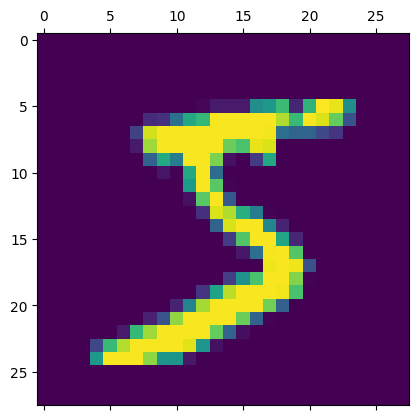

In [ ]:
plt.matshow(X_train[0])

In [ ]:
y_train[0]

5

y contains labels for each pic

We are going to flatten our pic, flatten 28 * 28 image into a single dimentional array that has 784 elements, we will get 784 neurons.

In [ ]:
print(X_train.shape)

(60000, 28, 28)


In [ ]:
X_train = X_train / 255
X_test = X_test / 255

scaling model

In [ ]:

X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [ ]:
X_train_flattened.shape


(60000, 784)

In [ ]:
X_train_flattened[0]

Now we create our NN with the following code

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])

model.compile(optimizer='adam',                                #compiles neural network, compulsory
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)           #training happenns here

scaling has imporved accuracy from 0.88 to 0.92

Dense means all the neurons in 1 layer connected to all neurons in 2nd layer

10 is no. of output layer,784 is no. of input layer

optimizer are compulsory to increase model efficiency

loss is loss function, look documentation, categorical as we dividing into categories



An "epoch" in machine learning signifies one complete iteration of the training data through the model during the training process, where the model's parameters are adjusted based on the computed loss to minimize the discrepancy between the predicted outputs and the actual labels



FIT will train the dataset, basically form the graph


now we evaluate dataset basically test efficfiency

In [ ]:
model.evaluate(X_test_flattened, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.2654 - accuracy: 0.9256


[0.2654350697994232, 0.925599992275238]

In [ ]:
y_predicted = model.predict(X_test_flattened)
print(y_predicted[1])

313/313 [==============================] - 1s 2ms/step
[3.6986423e-01 6.1378977e-03 9.9957657e-01 3.6411184e-01 1.5276405e-09
 8.4636170e-01 9.0850687e-01 8.1775287e-13 1.6742176e-01 2.4659512e-09]


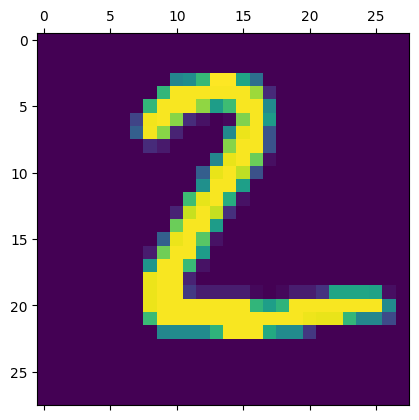

In [ ]:
plt.matshow(X_test[1])

np.argmax finds a maximum element from an array and returns the index of it

In [ ]:
np.argmax(y_predicted[1])

2

In [ ]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]
print(y_predicted_labels[:5])

[7, 2, 1, 0, 4]


In [ ]:
y_test[0:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [ ]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
print(cm)

tf.Tensor(
[[ 959    0    2    2    0    5    9    2    1    0]
 [   0 1113    3    2    0    1    4    2   10    0]
 [   4    9  936   12   10    3   11   10   33    4]
 [   3    0   29  914    1   23    1    9   19   11]
 [   1    1    5    1  916    0    9    3    8   38]
 [   9    3    6   33   11  773   15    6   29    7]
 [   9    3    8    1    8    9  916    2    2    0]
 [   1    6   24    6    9    1    0  937    2   42]
 [   7    7    7   24    9   27   10    9  860   14]
 [  10    7    2   10   25    6    0   13    4  932]], shape=(10, 10), dtype=int32)


Text(95.72222222222221, 0.5, 'Truth')

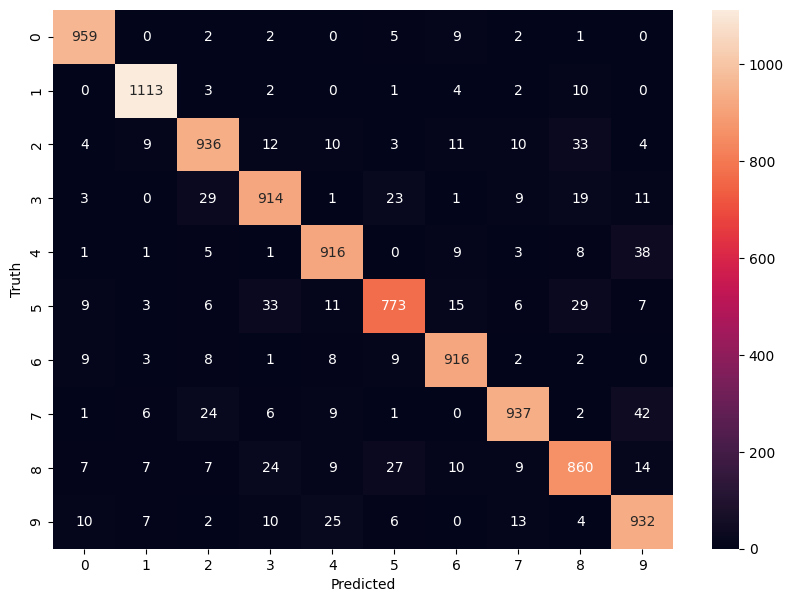

In [ ]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

**now we have created a model with no hidden layers that can predict numbers**



Now we will add a hidden layer


now hidden layer has 100 neurons

784 ---> 100 ---> 10

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')

])

model.compile(optimizer='adam',                                #compiles neural network, compulsory
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)

In [ ]:
model.evaluate(X_test_flattened,y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.0749 - accuracy: 0.9776


[0.07491845637559891, 0.9775999784469604]

hidden layer has increased accuracy

313/313 [==============================] - 1s 3ms/step


Text(95.72222222222221, 0.5, 'Truth')

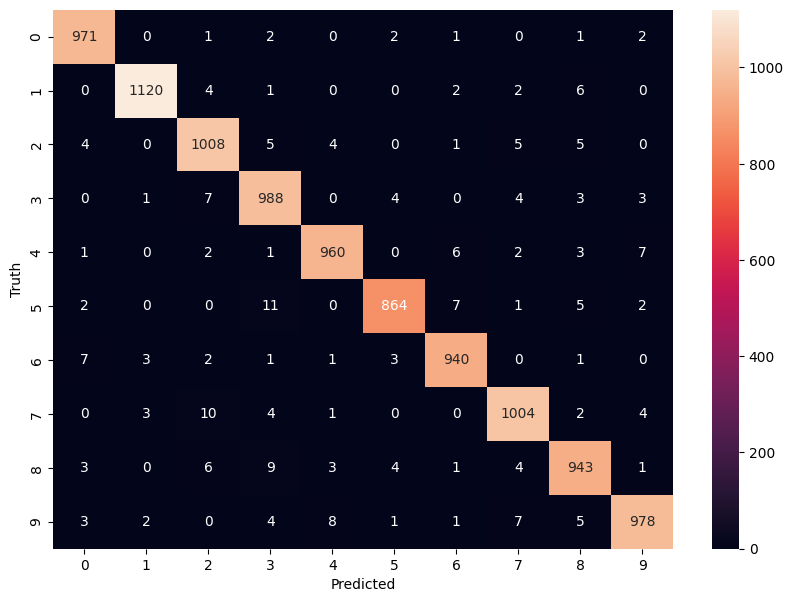

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),       #no need to flatten array here,same as before code
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])
tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10)